In [1]:
import pandas as pd

df = pd.read_csv("churn_cleaned.csv")

print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (3333, 70)
['Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn', 'State_AK', 'State_AL', 'State_AR', 'State_AZ', 'State_CA', 'State_CO', 'State_CT', 'State_DC', 'State_DE', 'State_FL', 'State_GA', 'State_HI', 'State_IA', 'State_ID', 'State_IL', 'State_IN', 'State_KS', 'State_KY', 'State_LA', 'State_MA', 'State_MD', 'State_ME', 'State_MI', 'State_MN', 'State_MO', 'State_MS', 'State_MT', 'State_NC', 'State_ND', 'State_NE', 'State_NH', 'State_NJ', 'State_NM', 'State_NV', 'State_NY', 'State_OH', 'State_OK', 'State_OR', 'State_PA', 'State_RI', 'State_SC', 'State_SD', 'State_TN', 'State_TX', 'State_UT', 'State_VA', 'State_VT', 'State_WA', 'State_WI', 'State_WV', 

In [2]:
# Behavioral/usage columns - what we'll actually cluster on
cluster_cols = [
    "Account length", "Number vmail messages",
    "Total day minutes", "Total day calls", "Total day charge",
    "Total eve minutes", "Total eve calls", "Total eve charge",
    "Total night minutes", "Total night calls", "Total night charge",
    "Total intl minutes", "Total intl calls", "Total intl charge",
    "Customer service calls"
]

X_cluster = df[cluster_cols]

print("Shape of clustering data:", X_cluster.shape)
print(X_cluster.head())

Shape of clustering data: (3333, 15)
   Account length  Number vmail messages  Total day minutes  Total day calls  \
0        0.676489               1.234883           1.566767         0.476643   
1        0.149065               1.307948          -0.333738         1.124503   
2        0.902529              -0.591760           1.168304         0.675985   
3       -0.428590              -0.591760           2.196596        -1.466936   
4       -0.654629              -0.591760          -0.240090         0.626149   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0          1.567036          -0.070610        -0.055940         -0.070427   
1         -0.334013          -0.108080         0.144867         -0.107549   
2          1.168464          -1.573383         0.496279         -1.573900   
3          2.196759          -2.742865        -0.608159         -2.743268   
4         -0.240041          -1.038932         1.098699         -1.037939   

   Total night minu

In [3]:
from sklearn.cluster import KMeans

# Create a K-Means model looking for 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit it to our data AND get cluster assignments in one step
df["Cluster"] = kmeans.fit_predict(X_cluster)

# How many customers landed in each cluster?
print(df["Cluster"].value_counts())

Cluster
2    1136
1    1134
0    1063
Name: count, dtype: int64


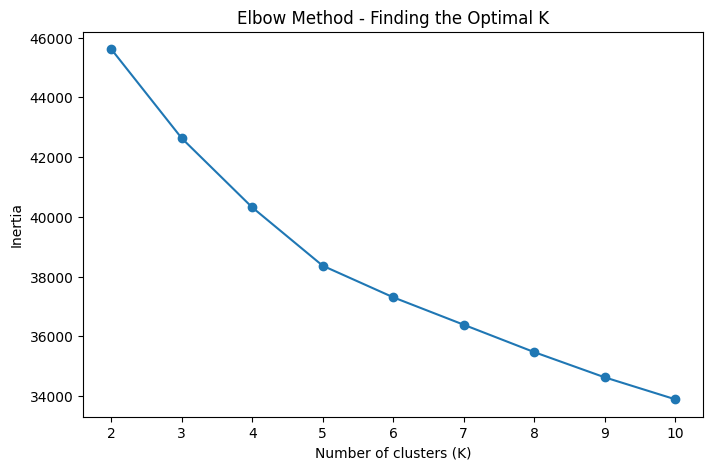

In [4]:
import matplotlib.pyplot as plt

inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_cluster)
    inertia_values.append(kmeans_test.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Finding the Optimal K")
plt.savefig("elbow_method.png", dpi=150, bbox_inches="tight")
plt.show()

K=2: Silhouette Score = 0.0848
K=3: Silhouette Score = 0.0777
K=4: Silhouette Score = 0.0760
K=5: Silhouette Score = 0.0772
K=6: Silhouette Score = 0.0776
K=7: Silhouette Score = 0.0704
K=8: Silhouette Score = 0.0696
K=9: Silhouette Score = 0.0719
K=10: Silhouette Score = 0.0759


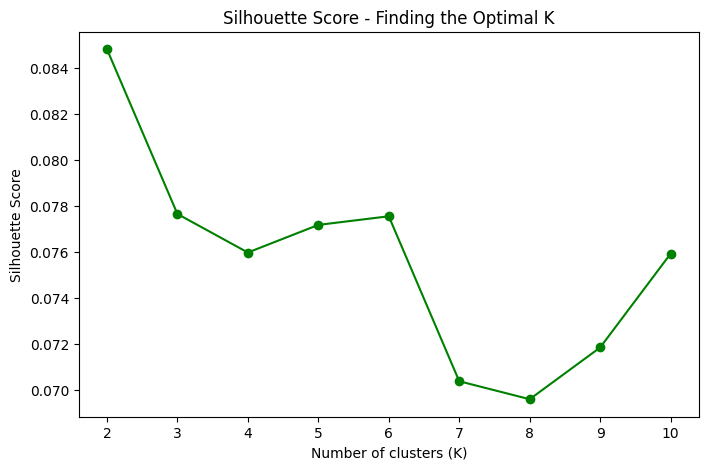

In [5]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_test.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range_sil, silhouette_scores, marker="o", color="green")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Finding the Optimal K")
plt.savefig("silhouette_scores.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Re-run K-Means with our chosen K=2
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X_cluster)

# How many customers in each cluster?
print(df["Cluster"].value_counts())

Cluster
1    1697
0    1636
Name: count, dtype: int64


Variance explained by each component: [0.13637648 0.13520688]
Total variance explained: 0.271583359883807


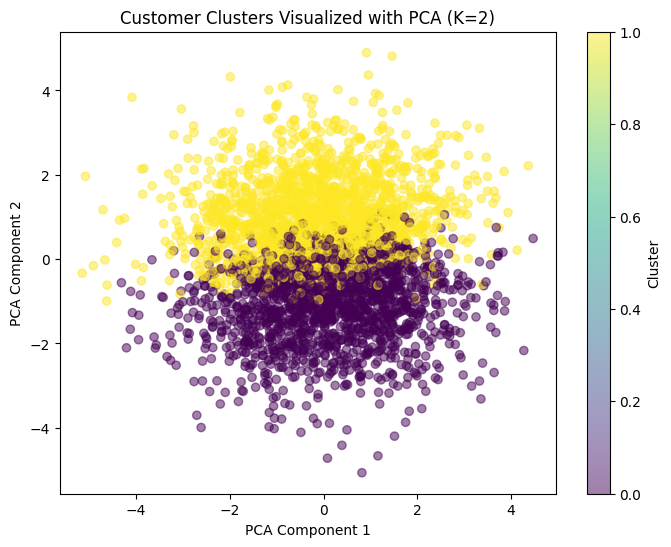

In [7]:
from sklearn.decomposition import PCA

# Reduce our 15 columns down to just 2 "PCA components"
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

# How much of the original information did we keep?
print("Variance explained by each component:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

# Plot the clusters using these 2 new dimensions
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"], cmap="viridis", alpha=0.5)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Clusters Visualized with PCA (K=2)")
plt.colorbar(scatter, label="Cluster")
plt.savefig("pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Compare the average value of each behavioral column, per cluster
cluster_summary = df.groupby("Cluster")[cluster_cols].mean()
print(cluster_summary)

         Account length  Number vmail messages  Total day minutes  \
Cluster                                                             
0             -0.009703               0.009648          -0.394974   
1              0.009354              -0.009301           0.380777   

         Total day calls  Total day charge  Total eve minutes  \
Cluster                                                         
0               0.014996         -0.394978          -0.462863   
1              -0.014457          0.380780           0.446225   

         Total eve calls  Total eve charge  Total night minutes  \
Cluster                                                           
0               0.027647         -0.462864             0.557196   
1              -0.026654          0.446226            -0.537167   

         Total night calls  Total night charge  Total intl minutes  \
Cluster                                                              
0                -0.007348            0.557237       